[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103683  178.955022  173.895982  174.013402  104487900
2022-01-04  175.843246  179.013714  175.275693  178.710370   99310400
2022-01-05  171.165802  176.303125  170.891813  175.755146   94537600
2022-01-06  168.308487  171.537664  167.956213  168.993460   96904000
2022-01-07  168.474838  170.402559  167.359306  169.179387   86709100


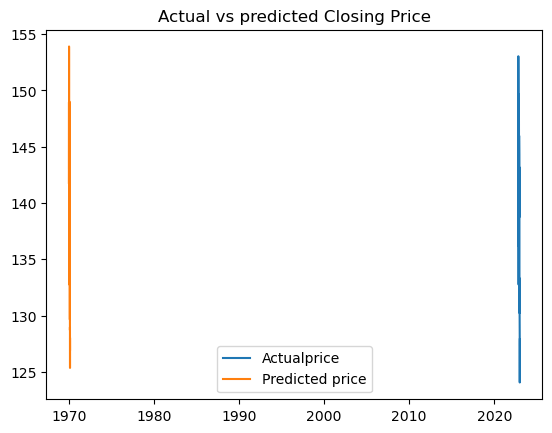

Next day PREDICTED CLOSE PRICE: [126.97382791]


In [5]:


#intasll these first
!pip install yfinance pandas numpy matplotlib scikit-learn

# step 1: import libaries

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# step 2: Download the stock data(you can change AAPL to TSLA, GOOGL etc.)

stock =yf.download("AAPL", start="2022-01-01", end="2023-01-01")

# step 3:Show data
print(stock.head())

#step 4:Select features (X) and target(y)
X=stock[["Open", "High", "Low", "Volume"]]
y=stock["Close"]

# step 5:Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

#step 6:Tarin model
model = LinearRegression()
model.fit(X_train, y_train)

#step 7:Make predictions
predictions = model.predict(X_test)

#step 8:Compare the result
plt.plot(y_test, label="Actualprice")
plt.plot(predictions, label="Predicted price")
plt.legend()
plt.title("Actual vs predicted Closing Price")
plt.show()

#step 9:predict next day(optional)
last_day=stock[['Open','High','Low','Volume']].tail(1)
next_day_prediction=model.predict(last_day)

print("Next day PREDICTED CLOSE PRICE:",next_day_prediction[0])



